# Pre-Arbitration: Do We Even Need a Model?

A companion to `war_value_exploration.ipynb`, focused on a single narrow question raised while looking
for a **deterministic** (non-agent) way to predict contract value: the project previously built a real
ML model for pre-arb salaries (`archive/v3/models/pre_arb/`, a scikit-learn `Ridge` pipeline over
age/service_time/contract_year/position). Is that model actually earning its complexity, or would a much
simpler year-over-year league-minimum trend line do just as well?

We test both **honestly** — trained only on 2011-2025 data, evaluated against the real 2026 pre-arb
contracts the model has never seen — rather than a random shuffle-split (which lets years leak across
train/test and overstates how well the model would do on a genuinely future year).

**Headline finding:** the simple trend-line beats the ML model, at a fraction of the complexity. Pre-arb
salaries have almost no real variance for a model to explain in the first place.


In [1]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", None)
DATASET_DIR = "../dataset"


## 1. What does pre-arb pay actually look like, year by year?

Filtering to the same population the archived model used: `contract_type == "pre-arb"`,
single-year deals (`duration == 1`), excluding outlier extensions (`value < $5M`).


In [2]:
df = pd.read_csv(f"{DATASET_DIR}/contracts_with_stats.csv")
pre = df[(df["contract_type"] == "pre-arb") & (df["duration"] == 1) & (df["value"] < 5.0)].copy()

yearly = pre.groupby("contract_year")["value"].agg(["count", "min", "mean", "median", "std"]).round(3)
yearly


,count,min,mean,median,std
contract_year,,,,,
2011,251,0.090,0.424,0.414,0.034
2012,366,0.115,0.488,0.480,0.037
2013,407,0.480,0.506,0.491,0.120
2014,424,0.342,0.517,0.501,0.107
2015,481,0.191,0.521,0.507,0.105
2016,549,0.507,0.520,0.508,0.076
2017,622,0.054,0.544,0.535,0.058
2018,691,0.545,0.561,0.545,0.085
2019,814,0.555,0.564,0.555,0.054


Two things stand out: the median rises in a fairly clean, close-to-linear trend from 2016 onward
(~$0.52M -> ~$0.79M, roughly $27K/year — matching the "~$30K/year" figure already noted in
`agent/predict/prompts.py`), and the **spread within a year is tiny and shrinking** — by 2023-2026 the
standard deviation is only $0.01-0.04M. There just isn't much variance left for age/service_time/position
to explain.


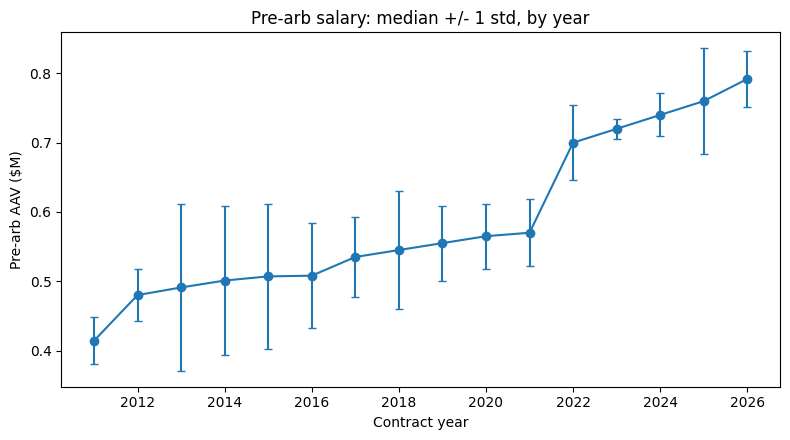

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(yearly.index, yearly["median"], yerr=yearly["std"], fmt="o-", capsize=3)
ax.set_xlabel("Contract year")
ax.set_ylabel("Pre-arb AAV ($M)")
ax.set_title("Pre-arb salary: median +/- 1 std, by year")
fig.tight_layout()


## 2. The honest test: train on 2011-2025, predict the real 2026 contracts

Three candidates, all evaluated against the same held-out `contract_year == 2026` rows:

1. **The archived ML model** — `Ridge(alpha=1.0)` over `age`, `service_time`, `contract_year`, and
   one-hot `position` (exact config from `archive/v3/models/pre_arb/config.py`).
2. **Flat baseline** — just predict last year's (2025) median for every 2026 player. No trend, no
   features.
3. **Trend-line baseline** — fit a straight line to the yearly median (2016 onward, past the noisier
   early-CBA-era years) and extrapolate it to 2026. This is the "just track the league minimum" idea.


In [4]:
train = pre[pre["contract_year"] < 2026]
test = pre[pre["contract_year"] == 2026]
print(f"train n={len(train)}   test n={len(test)}")

numeric = ["age", "service_time", "contract_year"]
categorical = ["position"]
preprocessor = ColumnTransformer([
    ("num", "passthrough", numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
])
model = Pipeline([("prep", preprocessor), ("model", Ridge(alpha=1.0))])

Xtr, ytr = train[numeric + categorical], train["value"]
Xte, yte = test[numeric + categorical], test["value"]
model.fit(Xtr, ytr)
pred_ridge = model.predict(Xte)


train n=9302   test n=389


In [5]:
def score(y_true, y_pred, label):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    within_250k = (np.abs(y_true - y_pred) <= 0.25).mean()
    within_100k = (np.abs(y_true - y_pred) <= 0.10).mean()
    return {
        "model": label, "n": len(y_true),
        "MAE_$K": round(mae * 1000, 1), "RMSE_$K": round(rmse * 1000, 1), "R2": round(r2, 3),
        "within_$250K": f"{within_250k*100:.1f}%", "within_$100K": f"{within_100k*100:.1f}%",
    }

baseline_flat = train.loc[train["contract_year"] == 2025, "value"].median()
pred_flat = np.full(len(yte), baseline_flat)

yearly_median = train.groupby("contract_year")["value"].median()
recent = yearly_median[yearly_median.index >= 2016]
slope, intercept = np.polyfit(recent.index, recent.values, 1)
trend_pred_2026 = slope * 2026 + intercept
pred_trend = np.full(len(yte), trend_pred_2026)

results = pd.DataFrame([
    score(yte, pred_ridge, "Ridge model (age+service_time+year+position)"),
    score(yte, pred_flat, f"Flat baseline (2025 median = ${baseline_flat:.3f}M)"),
    score(yte, pred_trend, f"Trend-line baseline (predicts ${trend_pred_2026:.3f}M for 2026)"),
])
results


,model,n,MAE_$K,RMSE_$K,R2,within_$250K,within_$100K
0,Ridge model (age+service_time+year+position),389,30.6,50.7,-0.624,99.2%,97.7%
1,Flat baseline (2025 median = $0.760M),389,39.0,55.7,-0.961,99.2%,97.4%
2,Trend-line baseline (predicts $0.787M for 2026),389,15.1,41.5,-0.089,99.2%,97.7%


**The trend-line baseline wins outright** — roughly half the MAE of the Ridge model, with a fraction of
the complexity (one slope, one intercept, no trained artifact to version or reload). The Ridge model's R²
on this real holdout is actually *negative* — not because it's broken, but because 2026 pre-arb salaries
have so little true variance (see Section 1) that even a small absolute error looks bad relative to it.
That's really a sign the *target itself* barely has anything left to explain, not a modeling failure.

**Why the extra features don't help:** age, service_time, and position all have some relationship to
pre-arb pay in theory, but in practice the CBA-driven minimum swamps everything else — there just isn't
enough real signal in those features for a model to reliably extract, so it ends up fitting noise instead
and doing slightly *worse* than just tracking the year trend.


## 3. What the trend-line prediction actually looks like

Sense-checking the trend-line baseline against the real distribution of 2026 pre-arb salaries, to make
sure a single flat number is actually a reasonable summary (not hiding a bimodal distribution or similar).


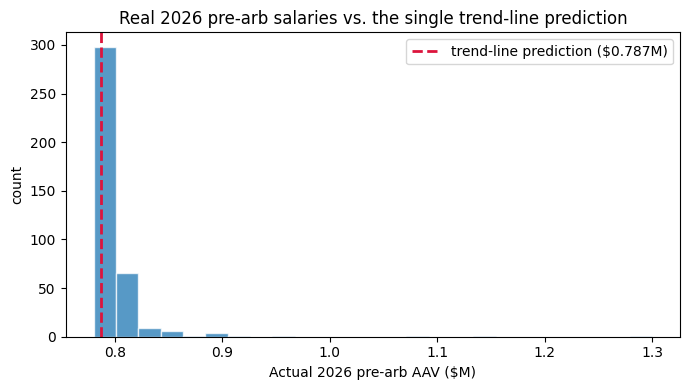

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(test["value"], bins=25, alpha=0.75, edgecolor="white")
ax.axvline(trend_pred_2026, color="crimson", linestyle="--", linewidth=2,
           label=f"trend-line prediction (${trend_pred_2026:.3f}M)")
ax.set_xlabel("Actual 2026 pre-arb AAV ($M)")
ax.set_ylabel("count")
ax.set_title("Real 2026 pre-arb salaries vs. the single trend-line prediction")
ax.legend()
fig.tight_layout()


The distribution is tight and right-skewed by a handful of outlier-ish deals (still under the $5M filter,
but above typical minimum) — the flat trend-line prediction sits right at the bulk of the distribution,
which is exactly why a single number performs so well here.

## 4. Can this trend line be extrapolated further, to 2027 or 2028?

Mechanically, yes — the same fitted line just needs a later year plugged in:


In [7]:
for yr in (2026, 2027, 2028):
    print(f"{yr} -> ${slope*yr + intercept:.3f}M")
print(f"\nimplied slope: ~${slope*1000:.1f}K/year")


2026 -> $0.787M
2027 -> $0.818M
2028 -> $0.848M

implied slope: ~$30.4K/year


But **2026 and 2027/2028 are not the same kind of extrapolation**, for a reason specific to this problem
rather than a generic "further out is shakier" concern: **the current CBA runs 2022-2026 and expires
after this season.** Every year in the training data — and the 2026 holdout that validated the trend
above — was governed by one known, contractually fixed minimum-salary schedule. 2027 would fall under a
**new, not-yet-negotiated CBA.**

That distinction matters because CBA renewals have historically changed the *structure* of pre-arb pay,
not just extended the same slope. The 2022 CBA itself is an example: it introduced the pre-arb bonus pool
as a new mechanism layered on top of the base minimum — a genuine step-change relative to the prior CBA's
trend, not a point that a straight-line extrapolation of the old trend would have landed on. A
post-lockout CBA has sometimes moved minimums sharply to make up for a shortened season, too. A linear fit
trained entirely on one CBA's schedule has no way to "know" whether the next one keeps the same escalator,
jumps discontinuously, or restructures the pay mechanism entirely.

**So: the 2026 prediction (Section 2) is a real, validated extrapolation — one year past the training
data, same CBA regime throughout.** 2027/2028 would be extrapolating **past a known regime change**,
which is a fundamentally different and much less trustworthy kind of extrapolation than "will the trend
hold a little further" — it's closer to "will the rules themselves still be the same."

**Practical takeaway:** keep using this trend-line approach for any year still inside a known CBA (2026
here). Treat predictions for years beyond the current CBA's term as **unreliable by construction** until
the new CBA is actually signed — at which point the right move is to hardcode/refit against the new CBA's
actual published minimum-salary schedule (announced directly by MLB/the union), not to keep extrapolating
the old line across the boundary.


## Conclusion

For pre-arb specifically, **skip the ML model** — a linear extrapolation of the league-minimum trend by
year is simpler, fully deterministic (no trained artifact to maintain/reload/version), and empirically
more accurate on a genuine held-out future year. This is the opposite conclusion from arbitration
(`war_value_exploration.ipynb`), where WAR and service_time carry real, learnable signal — pre-arb pay is
close to a pure function of *when* the contract was signed, not *who* signed it.

If this gets built into the actual prediction pipeline (`agent/predict/`), the natural next step is a
small deterministic module that fits (or hardcodes from known CBA figures) this trend and returns it
directly for pre-arb requests — no model artifact, no retraining step.
